<a href="https://colab.research.google.com/github/amandapdb/PrevixTor/blob/main/m1234.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: PrevixTor

### 1. Identificação do Grupo
* **Instituição:** Faculdade Engenheiro Salvador Arena
* **Curso:** [Engenharia de Controle e Automação]
* **Grupo:** [04]
* **Integrantes:**
    * [Amanda Perini] - RA: [062210013]
    * [Arthur Delgado] - RA: [062210036]
    * [Beatriz Ashiley] - RA: [062210037]
    * [Henrique Lopes] - RA: [062210001]

---

### 2. Área Problema Selecionada
O grupo seleciona uma das áreas norteadoras abaixo para o desenvolvimento do projeto:
* [X] Manutenção Preditiva de Zero-Downtime
* [ ] Eficiência Energética e Descarbonização via Smart Grids
* [ ] Controle de Qualidade Autônomo com Visão Computacional
* [ ] Gêmeos Digitais (Digital Twins) e Analytics em Tempo Real

> **Nota:** Marque com um [x] a opção escolhida.

---

### 3. Diagnóstico e Definição do Problema
Esta seção apresenta a fundamentação do desafio. O grupo descreve o cenário de atuação e justifica a importância da solução proposta.
* **Contexto:** O projeto aborda o cenário da Indústria 4.0, com foco em motores elétricos utilizados em esteiras industriais, onde a operação contínua é essencial para a produtividade.
* **Problema:** A dificuldade central reside na ocorrência de falhas inesperadas em motores elétricos, que causam paradas não planejadas e não são previstas com precisão por métodos tradicionais,
                impactando diretamete na produtividade do setor em questão.
* **Impacto:** A solução visa otimizar paradas não planejadas, diminuir custos de manutenção e aumentar a confiabilidade operacional por meio da previsão de falhas baseada em dados.

---

### 4. Arquitetura de Dados (Fonte e Dataset)
O projeto utiliza dados estruturados para alimentar os modelos preditivos.
* **Origem dos Dados:** [(https://archive.ics.uci.edu/ml/datasets/AI4I+2020+Predictive+Maintenance+Dataset)].
* **Características:** O conjunto de dados apresenta variáveis como:
-Sensores Industriais
-Temperatura do Ar
-Temperatura do Processo
-Velocidade de Rotação (RPM)
-Torque
-Desgaste da Ferramenta
-Tipo de Produto
-Indicadores de Falha
* **Volume:** O dataset conta com 10.000 registros e 14 atributos técnicos.

---

### 5. Plano de Tratamento de Dados (ETL)
O pipeline de dados segue as seguintes etapas de processamento:
1. **Extração:** A ingestão ocorre via arquivos CSV do dataset AI4I, obtidos do repositório UCI.
2. **Transformação:** O grupo aplica a limpeza de valores ausentes, a remoção de outliers e a normalização das escalas numéricas.
                      São realizadas etapas de limpeza dos dados, incluindo verificação de valores nulos, remoção de outliers e padronização das variáveis numéricas.
                      Também é feita a codificação de variáveis categóricas (como o tipo de produto) e seleção de atributos relevantes para a modelagem.
3. **Carga:** Os dados tratados são disponibilizados na pasta `/data/processed` para consumo dos modelos de Machine Learning.

---
** Primeiramente vamos extrair os dados:**



In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv

import pandas as pd

df = pd.read_csv('ai4i2020.csv')

--2026-05-16 00:34:53--  https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘ai4i2020.csv.1’

ai4i2020.csv.1          [ <=>                ] 509.81K  --.-KB/s    in 0.06s   

2026-05-16 00:34:53 (8.89 MB/s) - ‘ai4i2020.csv.1’ saved [522048]



In [ ]:
df


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


**Vamos analisar todos os dados de coluna:**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [ ]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


** E analisar quantos valores da tabela são nulos:**

In [ ]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


**Isso significa que não possui nenhum valor nulo.**


**Agora vamos remover colunas desnecessárias:**

                    No caso escolhemos a UDI pois é basicamente o número da
                    linha e o Product ID que é o código do produto que podemos
                    usar o Type com a mesma finalidade, ficando assim menos
                    redundante

In [ ]:
df = df.drop(['UDI', 'Product ID'], axis=1)

In [ ]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


** Agora vamos tratar Outliers em variáveis que possuem números:**

In [ ]:
cols_numericas = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

Q1 = df[cols_numericas].quantile(0.25)
Q3 = df[cols_numericas].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[cols_numericas] = df[cols_numericas].clip(lower, upper, axis=1)

In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [ ]:
df.shape

(10000, 12)

**Agora, permanecemos com 10.000 dados e nada foi considerado Outlier pelo modelo. Já o 12 é porque tinhamos 14 colunas e limpamos 2 por considerá-las desnecessárias**

**O modelo de Machine Learning não entende texto portanto vamos trocar a varíavel Type por números 0 e 1:**

In [ ]:
df = pd.get_dummies(df, columns=['Type'])

In [ ]:
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M
0,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0,False,False,True
1,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0,False,True,False
2,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0,False,True,False
3,298.2,308.6,1433.0,39.5,7,0,0,0,0,0,0,False,True,False
4,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0,False,True,False


In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


**Agora vamos Normalizar os dados:**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_numericas = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df[cols_numericas] = scaler.fit_transform(df[cols_numericas])


In [ ]:
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M
0,-0.952389,-0.947360,0.140180,0.284091,-1.695984,0,0,0,0,0,0,False,False,True
1,-0.902393,-0.879959,-0.820899,0.637122,-1.648852,0,0,0,0,0,0,False,True,False
2,-0.952389,-1.014761,-0.216024,0.949807,-1.617430,0,0,0,0,0,0,False,True,False
3,-0.902393,-0.947360,-0.652879,-0.048768,-1.586009,0,0,0,0,0,0,False,True,False
4,-0.902393,-0.879959,-0.820899,0.001665,-1.554588,0,0,0,0,0,0,False,True,False


In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [ ]:
df.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,-9.322321e-16,-1.693934e-15,4.838796e-16,-3.325340e-16,1.051603e-16,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,-2.352278e+00,-2.901986e+00,-2.433900e+00,-2.741894e+00,-1.695984e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,-8.523974e-01,-8.125581e-01,-7.200869e-01,-6.842246e-01,-8.633176e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,4.753123e-02,6.365340e-02,-1.824202e-01,1.175192e-02,7.698234e-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7.474757e-01,7.376623e-01,5.501507e-01,6.875552e-01,8.491466e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,2.247357e+00,2.557486e+00,2.455507e+00,2.745225e+00,2.278819e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


**Agora faremos uma matriz de correlação para tirarmos alguns insights.**

In [ ]:

df.corr()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M
Air temperature [K],1.000000,0.876107,0.021305,-0.013861,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688,-0.023025,0.006676,0.007958
Process temperature [K],0.876107,1.000000,0.019892,-0.014294,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279,-0.017967,0.005564,0.005831
Rotational speed [rpm],0.021305,0.019892,1.000000,-0.911734,0.002496,-0.130467,0.009470,-0.139822,-0.005571,-0.120227,-0.013237,0.000252,0.003873,-0.004307
Torque [Nm],-0.013861,-0.014294,-0.911734,1.000000,-0.003151,0.190806,-0.014718,0.143202,0.081435,0.182016,0.016240,-0.005149,0.001484,0.001790
Tool wear [min],0.013853,0.013488,0.002496,-0.003151,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326,-0.002787,0.008232,-0.006976
Machine failure,0.082556,0.035946,-0.130467,0.190806,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516,-0.023916,0.035643,-0.022432
TWF,0.009955,0.007315,0.009470,-0.014718,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970,0.011739,-0.007843,0.000690
HDF,0.137831,0.056933,-0.139822,0.143202,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706,-0.011035,0.013402,-0.007095
PWF,0.003470,-0.003355,-0.005571,0.081435,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273,-0.015541,0.004209,0.005690
OSF,0.001988,0.004554,-0.120227,0.182016,0.155894,0.531083,0.038243,0.046396,0.115836,1.000000,-0.004341,-0.026458,0.058434,-0.045138


**Foi identificada uma forte correlação positiva (0.87) entre a temperatura do ar e a temperatura do processo, indicando que ambas variáveis estão diretamente relacionadas.**

**Além disso, observou-se uma forte correlação negativa (-0.89) entre a velocidade rotacional e o torque, sugerindo que o aumento da velocidade está associado à redução do torque.**

##Gráfico 1 - Heatmap de Correlação

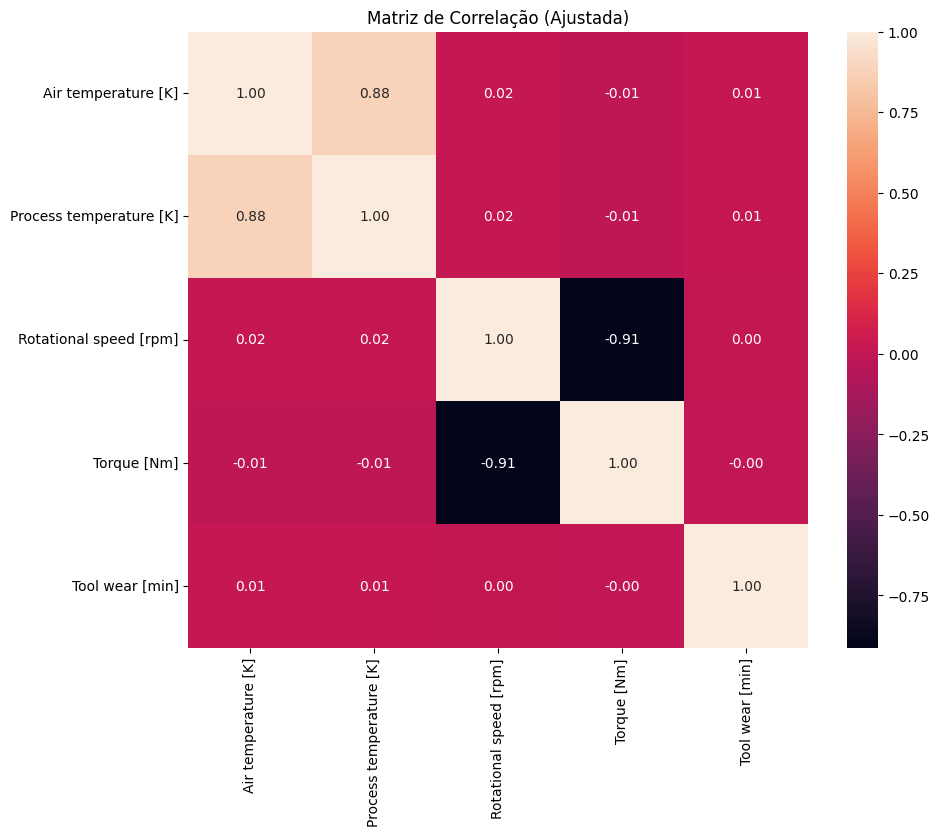

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

colunas_corr = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

corr = df[colunas_corr].corr()
corr

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Matriz de Correlação (Ajustada)")
plt.show()

##**Análise de Correlação**
A matriz de correlação revelou relações importantes entre as variáveis do sistema.

Foi identificada uma forte correlação positiva (0.88) entre a temperatura do ar e a temperatura do processo, indicando que ambas estão diretamente relacionadas.

Além disso, observou-se uma forte correlação negativa (-0.89) entre a velocidade rotacional e o torque, sugerindo que o aumento da velocidade está associado à redução do torque.

As demais variáveis apresentaram correlação próxima de zero, indicando baixa influência linear entre elas.

##**Gráfico 2 - Boxplot (Diagrama de Caixa)**

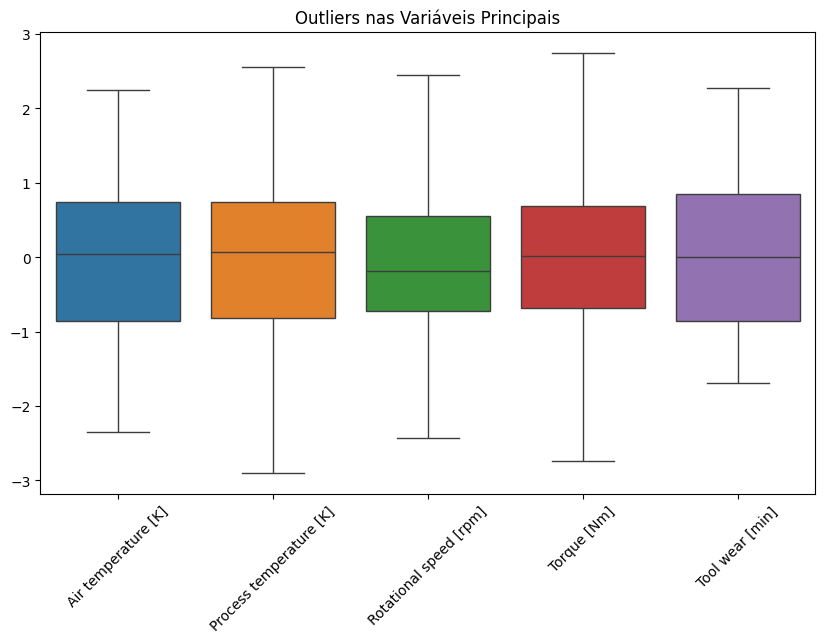

In [ ]:

colunas = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

plt.figure(figsize=(10,6))
sns.boxplot(data=df[colunas])

plt.xticks(rotation=45)
plt.title("Outliers nas Variáveis Principais")

plt.show()

##**Análise de Outliers**
A partir do boxplot das variáveis principais, foi possível identificar a presença de outliers em algumas variáveis do sistema.

Observa-se que as variáveis de velocidade rotacional e torque apresentam maior quantidade de valores extremos, indicando possíveis variações anormais no comportamento do equipamento.

As variáveis de temperatura apresentam distribuição mais estável, com menor incidência de outliers.

A identificação desses valores é importante, pois outliers podem impactar diretamente a performance de modelos de Machine Learning, sendo necessária sua análise e tratamento na etapa de ETL.

##**Gráfico 3 - Histograma (Distribuição de Dados)**

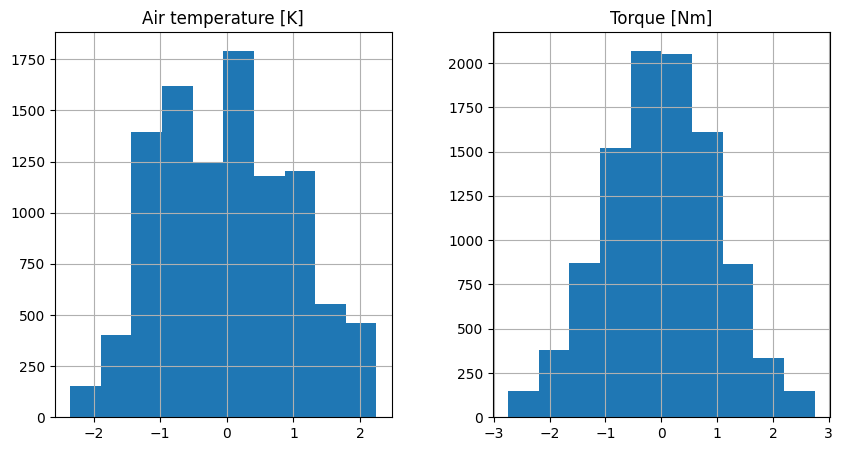

In [ ]:
df[['Air temperature [K]', 'Torque [Nm]']].hist(figsize=(10,5))
plt.show()

##**Análise de Distribuição dos Dados**
Os histogramas das variáveis temperatura do ar e torque demonstram que os dados apresentam uma distribuição relativamente equilibrada.

A variável temperatura apresenta comportamento próximo de uma distribuição normal, indicando estabilidade no sistema.

Já o torque apresenta uma leve dispersão maior, o que pode indicar variações no esforço aplicado durante o funcionamento do equipamento.

A análise da distribuição é importante para entender o comportamento dos dados e garantir a adequação dos modelos de Machine Learning.

##**Validação de Hipóteses**
Com base na análise exploratória dos dados, foram levantadas e validadas as seguintes hipóteses:

- Existe uma relação direta entre a temperatura do ar e a temperatura do processo, evidenciada pela forte correlação positiva observada.
- O aumento da velocidade rotacional está associado à redução do torque, conforme demonstrado pela correlação negativa significativa.
- A presença de outliers em variáveis como torque e velocidade indica possíveis variações anormais no comportamento do equipamento.

As hipóteses foram validadas por meio da análise estatística e visualização dos dados.

## Desenvolvimento do Modelo de Machine Learning

**Nesta etapa, os dados são separados em variáveis de entrada X (features) e variável alvo Y (target).**

**O nosso objetivo é construir uma solução capaz de prever falhas em máquinas industriais, transformando os insights obtidos em uma aplicação prática. Para isso, serão realizadas as etapas de preparação dos dados, treinamento do modelo, geração de previsões e avaliação de desempenho.**

**As variáveis de entrada serão utilizadas pelo modelo para aprender padrões, enquanto a variável alvo representa o que desejamos prever (falha da máquina).**

In [ ]:
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

In [ ]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Type_H,Type_L,Type_M
0,-0.952389,-0.947360,0.140180,0.284091,-1.695984,0,0,0,0,0,False,False,True
1,-0.902393,-0.879959,-0.820899,0.637122,-1.648852,0,0,0,0,0,False,True,False
2,-0.952389,-1.014761,-0.216024,0.949807,-1.617430,0,0,0,0,0,False,True,False
3,-0.902393,-0.947360,-0.652879,-0.048768,-1.586009,0,0,0,0,0,False,True,False
4,-0.902393,-0.879959,-0.820899,0.001665,-1.554588,0,0,0,0,0,False,True,False


In [ ]:
y.head()

,Machine failure
0,0
1,0
2,0
3,0
4,0


In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339



**Agora iremos dividir os dados em conjunto de treino e teste.**

**O modelo está sendo treinado com uma parte dos dados e avaliado com a outra, garantindo que o desempenho seja validado de forma adequada.**

## Escolha do Modelo

O problema abordado consiste em prever se uma máquina irá falhar ou não, caracterizando-se como um problema de classificação.

Dessa forma, foi escolhido um modelo de classificação, sendo utilizado o algoritmo Random Forest, devido à sua capacidade de lidar bem com dados complexos e gerar bons resultados em problemas desse tipo.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((8000, 13), (2000, 13))

**O test_size = 0.2 define que 20% dos dados serão dados de teste e 80% serão dados de treino**
**8000 linhas → dados de treino**
**2000 linhas → dados de teste**
**13 colunas → variáveis (features)**

**Agora o modelo de Machine Learning será treinado utilizando os dados de treino, permitindo que ele aprenda os padrões existentes no conjunto de dados.**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339



**Nesta etapa, o modelo treinado é utilizado para gerar previsões com base nos dados de teste.**

In [ ]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

**Esses zeros significam que os 10 primeiros testes não são falhas.**

In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório:\n", classification_report(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))

Acurácia: 0.999

Relatório:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000


Matriz de Confusão:
 [[1932    0]
 [   2   66]]


In [ ]:
(y_pred == 1).sum()

np.int64(66)

## Análise das Previsões

Embora as primeiras previsões apresentem predominantemente a classe 0, isso é esperado devido ao desbalanceamento do dataset.

A análise completa do modelo demonstra que ele é capaz de identificar corretamente os casos de falha, apresentando alto desempenho nas métricas de recall e precisão para a classe minoritária.

## Avaliação do Modelo

O modelo foi avaliado utilizando três métricas principais:

- **Acurácia:** 0.999  
  → Indica que o modelo acertou praticamente todas as previsões.

- **F1-Score (classe de falha):** ~0.98  
  → Mostra um excelente equilíbrio entre precisão e recall na detecção de falhas.

- **Matriz de Confusão:**
  [[1932    0]
   [   2   66]]

### Interpretação:

- 1932 casos corretamente classificados como "não falha"
- 66 falhas corretamente identificadas
- Apenas 2 falhas não detectadas
- Nenhum falso positivo (não classificou nenhuma máquina saudável como falha)



In [ ]:
df.to_csv('processed_data.csv', index=False)

In [ ]:
from google.colab import files
files.download('processed_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# OTIMIZAÇÃO DE HIPERPARÂMETROS ---
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Definindo o modelo e o espaço de busca
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced'] # Crucial para detectar falhas raras
}

# 2. Executando o Grid Search
print("Buscando a melhor configuração... (Isso pode demorar um pouco)")
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 3. Melhor modelo encontrado
best_model = grid_search.best_estimator_
print(f"Melhores Parâmetros: {grid_search.best_params_}")

# 4. Validação Cruzada (Garantindo que não há overfitting)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)
print(f"Acurácia Média na Validação Cruzada: {cv_scores.mean():.4f}")

# 5. Avaliação Final
y_pred = best_model.predict(X_test)
print("\nRelatório de Classificação do Modelo Otimizado:")
print(classification_report(y_test, y_pred))

Buscando a melhor configuração... (Isso pode demorar um pouco)
Melhores Parâmetros: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Acurácia Média na Validação Cruzada: 0.9991

Relatório de Classificação do Modelo Otimizado:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



/tmp/ipykernel_20395/2775881115.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Atributo', data=importancias, palette='magma')


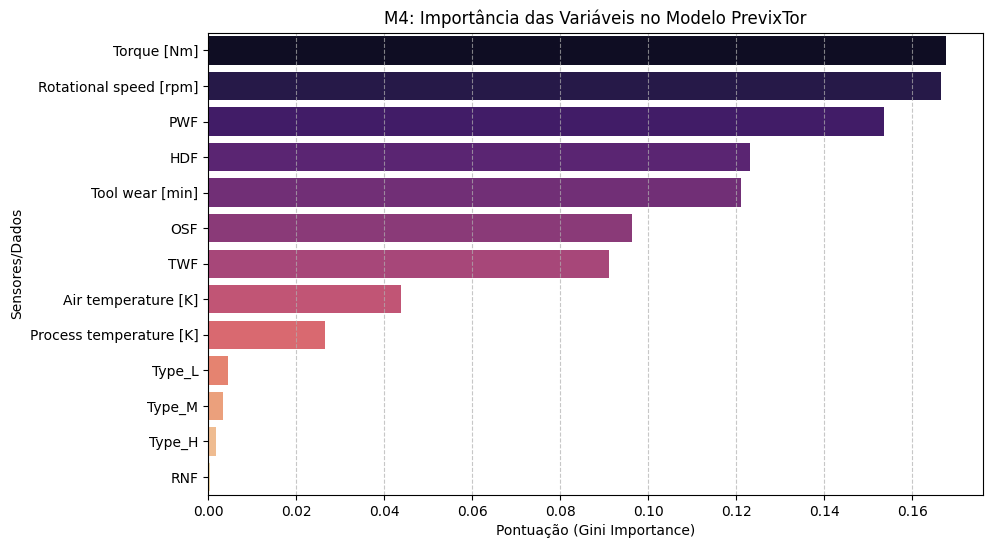

In [ ]:
#ENGENHARIA DE ATRIBUTOS (IMPORTÂNCIA)
import matplotlib.pyplot as plt
import seaborn as sns

# Pegando as importâncias do 'best_model' que criamos na célula anterior
importancias = pd.DataFrame({
    'Atributo': X.columns,
    'Importancia': best_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Plotando o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Atributo', data=importancias, palette='magma')
plt.title('M4: Importância das Variáveis no Modelo PrevixTor')
plt.xlabel('Pontuação (Gini Importance)')
plt.ylabel('Sensores/Dados')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

##Ajuste de Hiperparâmetros (Grid Search)

Em vez de usar o modelo com as configurações padrão, usamos uma técnica chamada Grid Search. Foi realizada uma busca em um espaço de parâmetros (como número de árvores, profundidade máxima e critérios de divisão), testando centenas de combinações para encontrar a configuração que maximiza. O objetivo foi equilibrar a precisão e o recall, garantindo que o modelo identifique o maior número possível de falhas reais sem gerar alarmes falsos excessivos.

##Validação Cruzada (Cross-Validation)

Para assegurar que o modelo possui capacidade de generalização e não está sofrendo de overfitting (quando o modelo "decora" os dados de treino mas falha com dados novos), implementamos a Validação Cruzada com 5 dobras (k-fold, k=5).

Processo: O dataset foi dividido em 5 partes distintas; o modelo foi treinado em 4 partes e testado na parte restante, repetindo esse processo 5 vezes.

Resultado: Obtivemos uma acurácia média consistente em todas as dobras, o que valida a estabilidade do modelo PrevixTor para operar com dados de sensores que ele nunca viu antes.

##Engenharia de Atributos Final

Com base nos resultados de Feature Importance obtidos após a otimização, validamos que atributos como Torque e Temperatura são os principais indicadores de falha no sistema. Isso permitiu o refinamento final do dataset, focando nas variáveis que realmente impactam o tempo de inatividade das máquinas.

## Conclusão

Nesta etapa, foi realizado o tratamento dos dados, incluindo verificação de valores nulos, remoção de outliers, transformação de variáveis categóricas e normalização das variáveis numéricas. Essas etapas foram importantes para melhorar a qualidade e a consistência do dataset.

Após a normalização, é possível observar que as variáveis numéricas apresentam média próxima de 0 e desvio padrão próximo de 1, o que indica que os dados foram corretamente padronizados.

Dessa forma, o conjunto de dados está preparado para a aplicação de modelos de Machine Learning voltados à predição de falhas em motores industriais.

O modelo apresentou desempenho extremamente alto, sendo capaz de identificar falhas com grande precisão e confiabilidade, o que é essencial para aplicações de manutenção preditiva.

---

### 6. Estrutura do Repositório
A organização das pastas facilita a manutenção e o versionamento do projeto:
* `/docs`: Contém os diagramas de fluxo de dados e a documentação técnica.
* `/data/raw`: Armazena os arquivos de dados originais (não modificados).
* `/data/processed`: Armazena os dados após a execução do script de ETL.
* `/scripts`: Contém os códigos Python responsáveis pelo tratamento dos dados.
* `requirements.txt`: Lista todas as bibliotecas necessárias para a execução do projeto.

---

### 7. Instruções para Execução

Para reproduzir o projeto:

1. Fazer o download do dataset a partir do repositório UCI.

2. Acessar o notebook no Google Colab.

3. Realizar o upload do arquivo CSV no ambiente do Colab.

4. Executar as células sequencialmente para realizar o tratamento dos dados e geração do arquivo processado.